In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import shap
import time
!pip install lime
!pip install catboost
from lime import lime_tabular
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, roc_curve, auc

# Authenticate Kaggle (using your provided keys)
# I used my private Kaggle username and key for this part of the code and I'm not putting it up for this submission.

# Download and locate the dataset
path = kagglehub.dataset_download("ethon0426/lending-club-20072020q1")
file_path = os.path.join(path, "Loan_status_2007-2020Q3.gzip")

# Columns identified for the Top 10 features
cols_to_use = [
    'loan_status', 'loan_amnt', 'last_pymnt_amnt', 'avg_cur_bal',
    'int_rate', 'installment', 'grade', 'annual_inc', 'dti',
    'revol_util', 'revol_bal'
]

# Memory-efficient balanced sampling: 10k Fully Paid, 10k Charged Off
chunk_size = 50000
df_list = []
counts = {'Fully Paid': 0, 'Charged Off': 0}

for chunk in pd.read_csv(file_path, usecols=cols_to_use, chunksize=chunk_size, low_memory=False):
    filtered_chunk = chunk[chunk['loan_status'].isin(['Fully Paid', 'Charged Off'])]
    for status in ['Fully Paid', 'Charged Off']:
        if counts[status] < 10000:
            needed = 10000 - counts[status]
            subset = filtered_chunk[filtered_chunk['loan_status'] == status].head(needed)
            df_list.append(subset)
            counts[status] += len(subset)
    if counts['Fully Paid'] >= 10000 and counts['Charged Off'] >= 10000:
        break

df_sample = pd.concat(df_list).reset_index(drop=True)
print(f"Balanced sample created: {df_sample['loan_status'].value_counts().to_dict()}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=173d93f2c0d7c518475da22dd94494a8cf319d71875f0a80374b492e3c9667a3
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.9 MB/s eta 0:00:00


100%|██████████| 482M/482M [00:03<00:00, 151MB/s]

Extracting files...


Balanced sample created: {'Fully Paid': 10000, 'Charged Off': 10000}


In [ ]:
# Mapping & Cleaning [cite: 155, 157, 169]
df_sample['target'] = df_sample['loan_status'].map({'Fully Paid': 0, 'Charged Off': 1})
df_sample['grade'] = df_sample['grade'].map({'A':1, 'B':2, 'C':3, 'D':4, 'E':5, 'F':6, 'G':7})

for col in ['int_rate', 'revol_util']:
    if df_sample[col].dtype == 'object':
        df_sample[col] = df_sample[col].str.rstrip('%').astype(float)

features = ['loan_amnt', 'last_pymnt_amnt', 'avg_cur_bal', 'int_rate', 'installment',
            'grade', 'annual_inc', 'dti', 'revol_util', 'revol_bal']
X = df_sample[features].fillna(0)
y = df_sample['target']

# 70% Train, 20% Test, 10% Validation split
X_train_raw, X_rem_raw, y_train, y_rem = train_test_split(X, y, train_size=0.70, random_state=0, stratify=y)
X_test_raw, X_val_raw, y_test, y_val = train_test_split(X_rem_raw, y_rem, test_size=0.33, random_state=0, stratify=y_rem)

# Normalization [cite: 162]
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)
X_val = scaler.transform(X_val_raw)

print(f"Sets created - Train: {len(X_train)}, Test: {len(X_test)}, Val: {len(X_val)}")

Sets created - Train: 14000, Test: 4020, Val: 1980


[LightGBM] [Info] Number of positive: 6990, number of negative: 7010
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006920 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2246
[LightGBM] [Info] Number of data points in the train set: 14000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499286 -> initscore=-0.002857
[LightGBM] [Info] Start training from score -0.002857
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


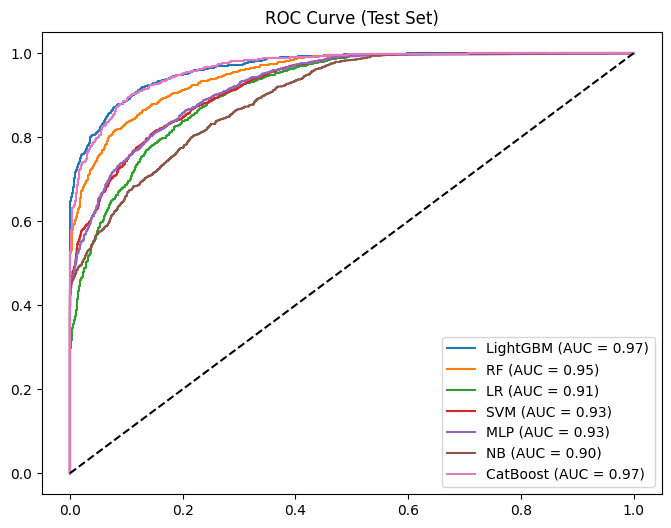

      Model  Test Accuracy
0  LightGBM           0.89
1        RF           0.86
2        LR           0.82
3       SVM           0.83
4       MLP           0.83
5        NB           0.72
6  CatBoost           0.90


In [ ]:
# Define models with paper parameters [cite: 571]
lgbm_model = LGBMClassifier(
    n_estimators=250,
    learning_rate=0.3,
    max_depth=3,
    reg_alpha=4,
    reg_lambda=5,
    min_data_in_leaf=20,
    random_state=0,
    scale_pos_weight=4,
    importance_type='gain')

models = {
    "LightGBM": lgbm_model,
    "RF": RandomForestClassifier(n_estimators=100, min_samples_leaf=10, max_depth=20, random_state=0),
    "LR": LogisticRegression(C=10, random_state=1),
    "SVM": SVC(C=10, kernel='rbf', probability=True, random_state=0),
    "MLP": MLPClassifier(hidden_layer_sizes=(5,2), alpha=1e-5, max_iter=300, random_state=1),
    "NB": GaussianNB(),
    "CatBoost": CatBoostClassifier(iterations=1000, depth=10, learning_rate=0.5, l2_leaf_reg=5, random_state=0, verbose=0)
}

# Training and testing on the Test set (for bug fixing/satisfaction)
results = []
plt.figure(figsize=(8, 6))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, model.predict(X_test))
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.2f})')
    results.append({"Model": name, "Test Accuracy": round(acc, 2)})

plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve (Test Set)")
plt.legend()
plt.show()

print(pd.DataFrame(results))

FINAL UNSEEN ACCURACY: 0.8919


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


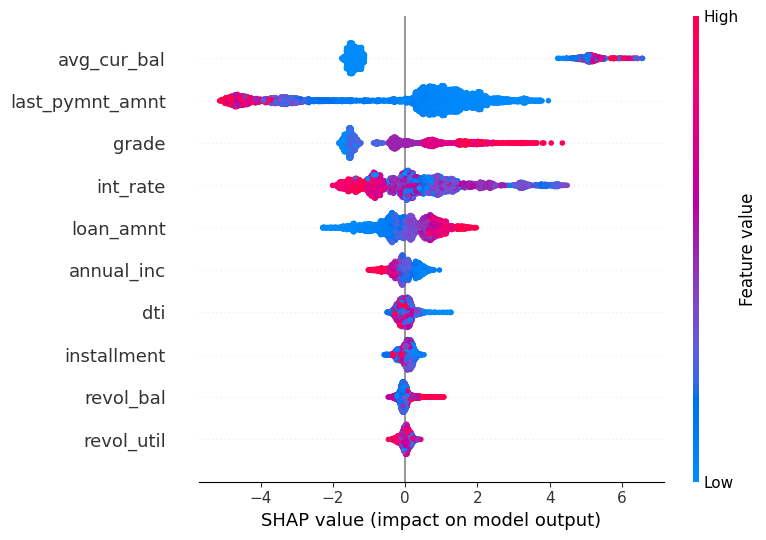

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# --- FINAL UNSEEN VALIDATION ---
final_pred = lgbm_model.predict(X_val)
print(f"FINAL UNSEEN ACCURACY: {accuracy_score(y_val, final_pred):.4f}")

# --- SHAP Global Explanation (Fig 6) ---
explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, feature_names=features)

# --- LIME Local Explanation (Fig 9) ---
lime_explainer = lime_tabular.LimeTabularExplainer(X_train, feature_names=features, class_names=['Paid', 'Default'], mode='classification')
exp = lime_explainer.explain_instance(X_val[0], lgbm_model.predict_proba)
exp.show_in_notebook()

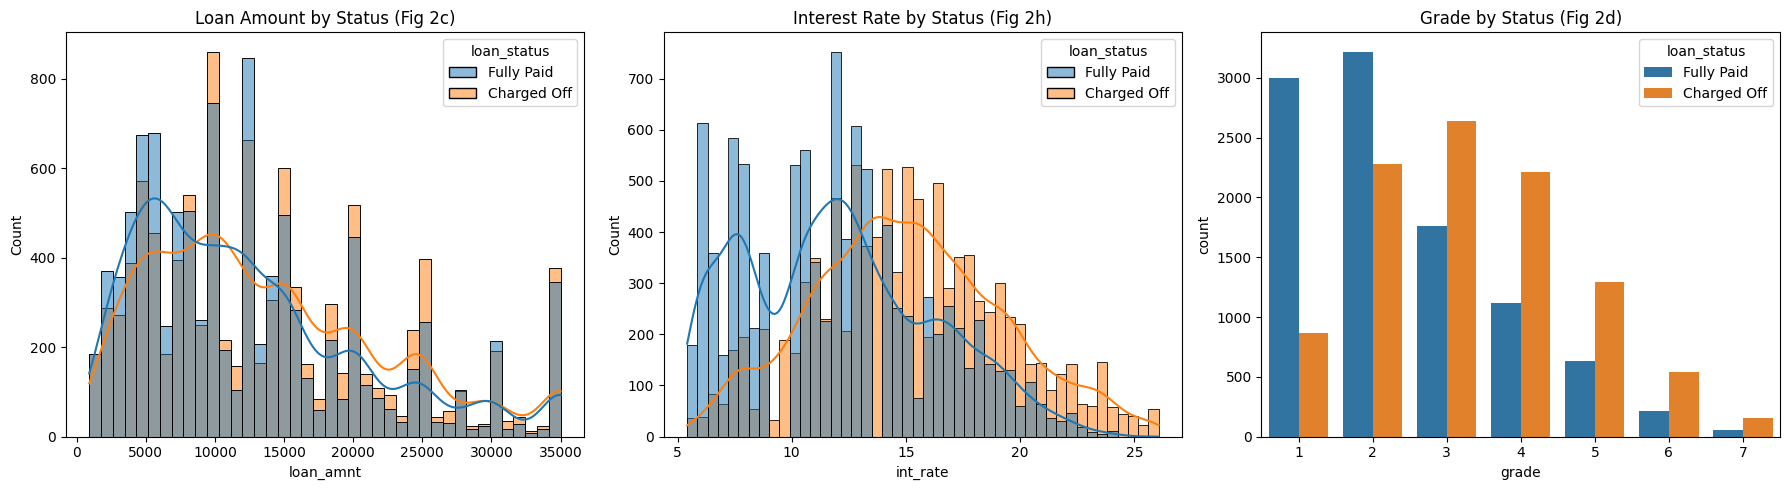

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Replicating the distribution analysis from Figure 2
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Loan Amount Distribution [cite: 168]
sns.histplot(data=df_sample, x='loan_amnt', hue='loan_status', kde=True, ax=axes[0])
axes[0].set_title('Loan Amount by Status (Fig 2c)')

# (b) Interest Rate Distribution [cite: 171]
sns.histplot(data=df_sample, x='int_rate', hue='loan_status', kde=True, ax=axes[1])
axes[1].set_title('Interest Rate by Status (Fig 2h)')

# (c) Grade Distribution [cite: 169]
sns.countplot(data=df_sample, x='grade', hue='loan_status', ax=axes[2])
axes[2].set_title('Grade by Status (Fig 2d)')

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


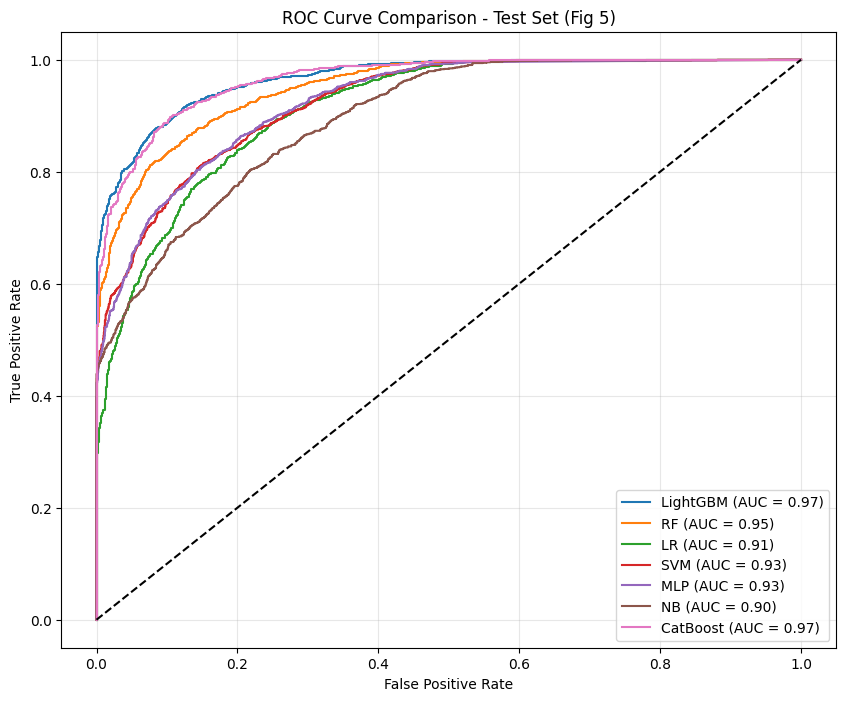

In [ ]:
plt.figure(figsize=(10, 8))

for name, model in models.items():
    # Evaluate on the Test Set only
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve Comparison - Test Set (Fig 5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


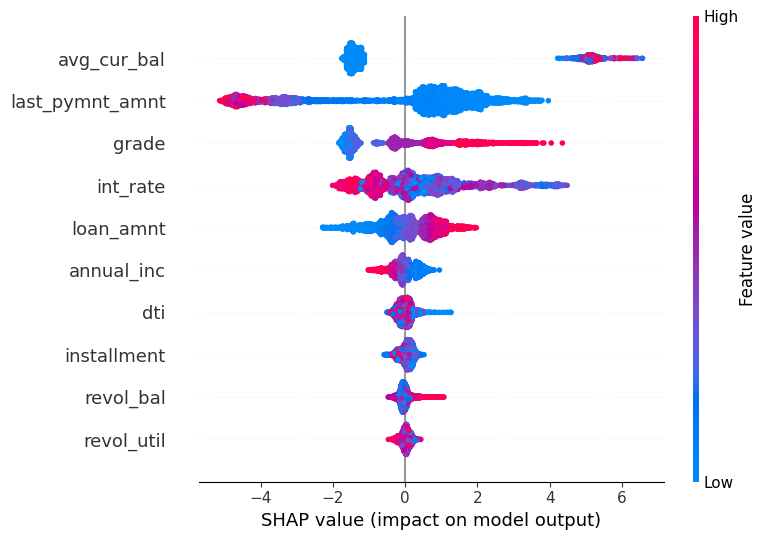

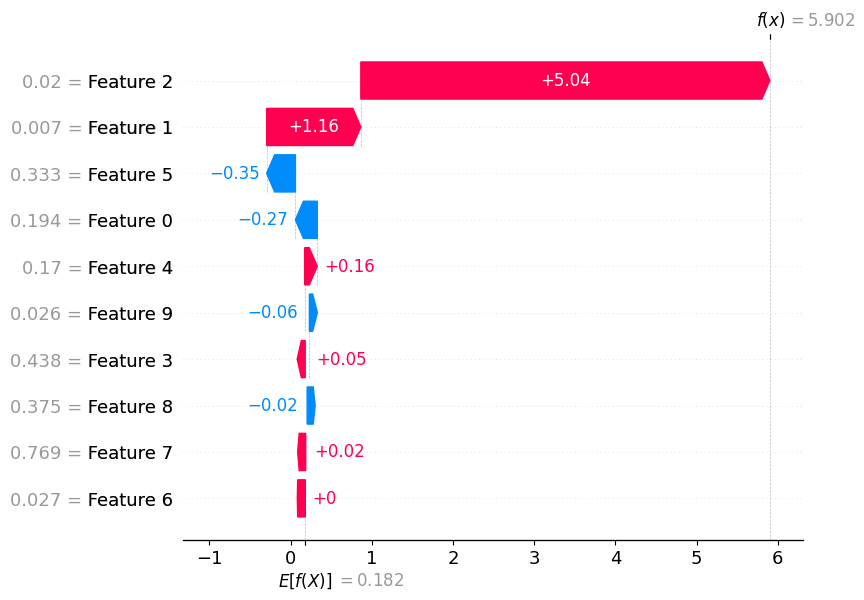

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# --- Global: SHAP Variable Significance (Fig 6) ---
# This identifies 'last_pymnt_amnt' as the top predictor [cite: 594]
explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, feature_names=features)

# --- Global: Waterfall Plot (Fig 7a) ---
# Shows how features drive a single prediction toward or away from default [cite: 603]
shap.plots.waterfall(explainer(X_test)[0])

# --- Local: LIME Explanation (Fig 9) ---
# Used for a single "Borrower A" instance [cite: 724, 799]
lime_explainer = lime_tabular.LimeTabularExplainer(
    X_train, feature_names=features, class_names=['Paid', 'Default'], mode='classification'
)
exp = lime_explainer.explain_instance(X_test[0], lgbm_model.predict_proba)
exp.show_in_notebook()

In [ ]:
# Final evaluation on the UNTOUCHED validation set
final_val_pred = lgbm_model.predict(X_val)
final_val_prob = lgbm_model.predict_proba(X_val)[:, 1]

print("--- FINAL UNSEEN VALIDATION RESULTS ---")
print(f"Accuracy: {accuracy_score(y_val, final_val_pred):.4f}")
print(f"AUC: {roc_auc_score(y_val, final_val_prob):.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


--- FINAL UNSEEN VALIDATION RESULTS ---
Accuracy: 0.8919
AUC: 0.9699


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

results_table = []

for name, model in models.items():
    # Per professor's instruction: Evaluate on the Test Set for final tuning check
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results_table.append({
        "Model": name,
        "AUC": round(roc_auc_score(y_test, y_prob), 2),
        "Accuracy": round(accuracy_score(y_test, y_pred), 2),
        "Precision": round(precision_score(y_test, y_pred), 2),
        "Recall": round(recall_score(y_test, y_pred), 2),
        "F1-Score": round(f1_score(y_test, y_pred), 2)
    })

df_table_6 = pd.DataFrame(results_table)
print("--- Final Model Comparison (Test Set) ---")
print(df_table_6)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


--- Final Model Comparison (Test Set) ---
      Model   AUC  Accuracy  Precision  Recall  F1-Score
0  LightGBM  0.97      0.89       0.90    0.88      0.89
1        RF  0.95      0.86       0.85    0.89      0.87
2        LR  0.91      0.82       0.81    0.84      0.82
3       SVM  0.93      0.83       0.80    0.87      0.83
4       MLP  0.93      0.83       0.85    0.80      0.82
5        NB  0.90      0.72       1.00    0.44      0.61
6  CatBoost  0.97      0.90       0.90    0.89      0.90


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


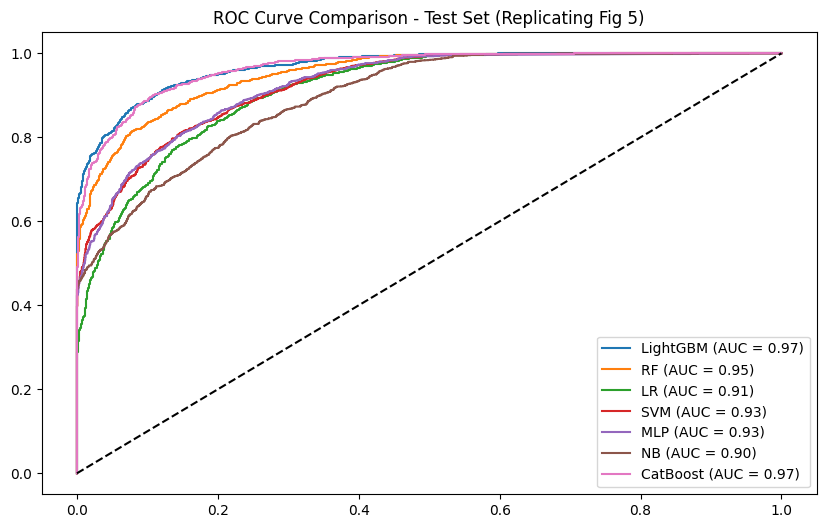

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


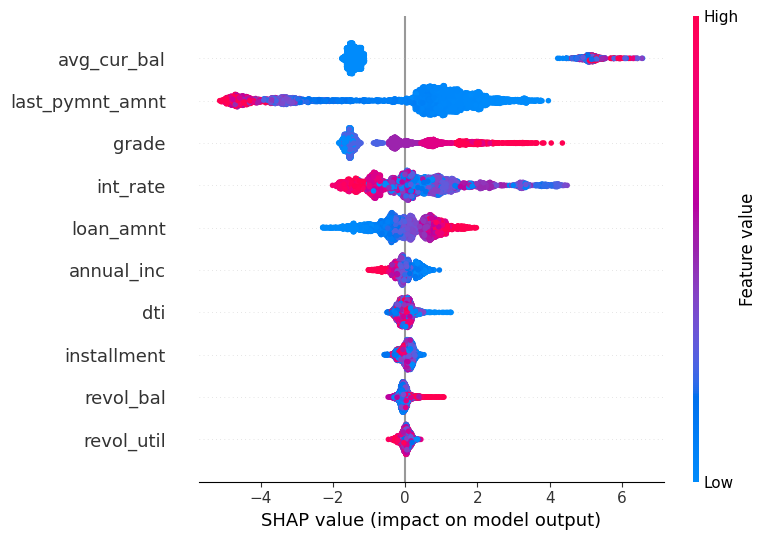

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [ ]:
# --- Figure 5: ROC Curve Comparison ---
plt.figure(figsize=(10, 6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve Comparison - Test Set (Replicating Fig 5)')
plt.legend()
plt.show()

# --- Figure 6: Global Feature Importance (SHAP) ---
# Identifies top features like last_pymnt_amnt [cite: 594, 653, 743]
explainer = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, feature_names=features)

# --- Figure 9: Local Explanation (LIME) ---
# Provides instance-level transparency for "Borrower A" [cite: 481, 724, 799]
lime_explainer = lime_tabular.LimeTabularExplainer(
    X_train,
    feature_names=features,
    class_names=['Paid', 'Default'],
    mode='classification'
)
# Explaining the first instance of the Validation set
exp = lime_explainer.explain_instance(X_val[0], lgbm_model.predict_proba)
exp.show_in_notebook()

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# 1. Automatically find the path to avoid FileNotFoundError
path = kagglehub.dataset_download("ethon0426/lending-club-20072020q1")
file_path = ""
for root, dirs, files in os.walk(path):
    for file in files:
        if file.endswith(".gzip") or file.endswith(".csv"):
            file_path = os.path.join(root, file)
            break

# 2. Memory-efficient balanced sampling (Replicating Section 2.2)
cols_to_use = ['loan_status', 'loan_amnt', 'last_pymnt_amnt', 'avg_cur_bal',
               'int_rate', 'installment', 'grade', 'annual_inc', 'dti',
               'revol_util', 'revol_bal', 'issue_d']

chunk_size = 50000
df_list = []
counts = {'Fully Paid': 0, 'Charged Off': 0}

# Pulling 20,000 balanced records [# cite: 192]
for chunk in pd.read_csv(file_path, usecols=cols_to_use, chunksize=chunk_size, low_memory=False):
    filtered_chunk = chunk[chunk['loan_status'].isin(['Fully Paid', 'Charged Off'])]
    for status in ['Fully Paid', 'Charged Off']:
        if counts[status] < 10000:
            needed = 10000 - counts[status]
            subset = filtered_chunk[filtered_chunk['loan_status'] == status].head(needed)
            df_list.append(subset)
            counts[status] += len(subset)
    if counts['Fully Paid'] >= 10000 and counts['Charged Off'] >= 10000:
        break

df_sample = pd.concat(df_list).reset_index(drop=True)

# 3. Preprocessing (Section 2.1)
df_sample['target'] = df_sample['loan_status'].map({'Fully Paid': 0, 'Charged Off': 1}) # [cite: 155, 157]
df_sample['grade'] = df_sample['grade'].map({'A':1, 'B':2, 'C':3, 'D':4, 'E':5, 'F':6, 'G':7}) # [cite: 158, 169]

for col in ['int_rate', 'revol_util']:
    if df_sample[col].dtype == 'object':
        df_sample[col] = df_sample[col].str.rstrip('%').astype(float) # [cite: 156, 159]

features = ['loan_amnt', 'last_pymnt_amnt', 'avg_cur_bal', 'int_rate', 'installment',
            'grade', 'annual_inc', 'dti', 'revol_util', 'revol_bal']
X = df_sample[features].fillna(0) # [cite: 149]
y = df_sample['target']

# 4. Professor's Split: 70/20/10
X_train_raw, X_rem_raw, y_train, y_rem = train_test_split(X, y, train_size=0.70, random_state=0)
X_test_raw, X_val_raw, y_test, y_val = train_test_split(X_rem_raw, y_rem, test_size=0.33, random_state=0)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train_raw) # [cite: 160, 162]
X_test = scaler.transform(X_test_raw)
X_val = scaler.transform(X_val_raw)

print(f"Data ready. Training: {len(X_train)}, Testing: {len(X_test)}, Validation: {len(X_val)}")

Using Colab cache for faster access to the 'lending-club-20072020q1' dataset.
Data ready. Training: 14000, Testing: 4020, Validation: 1980


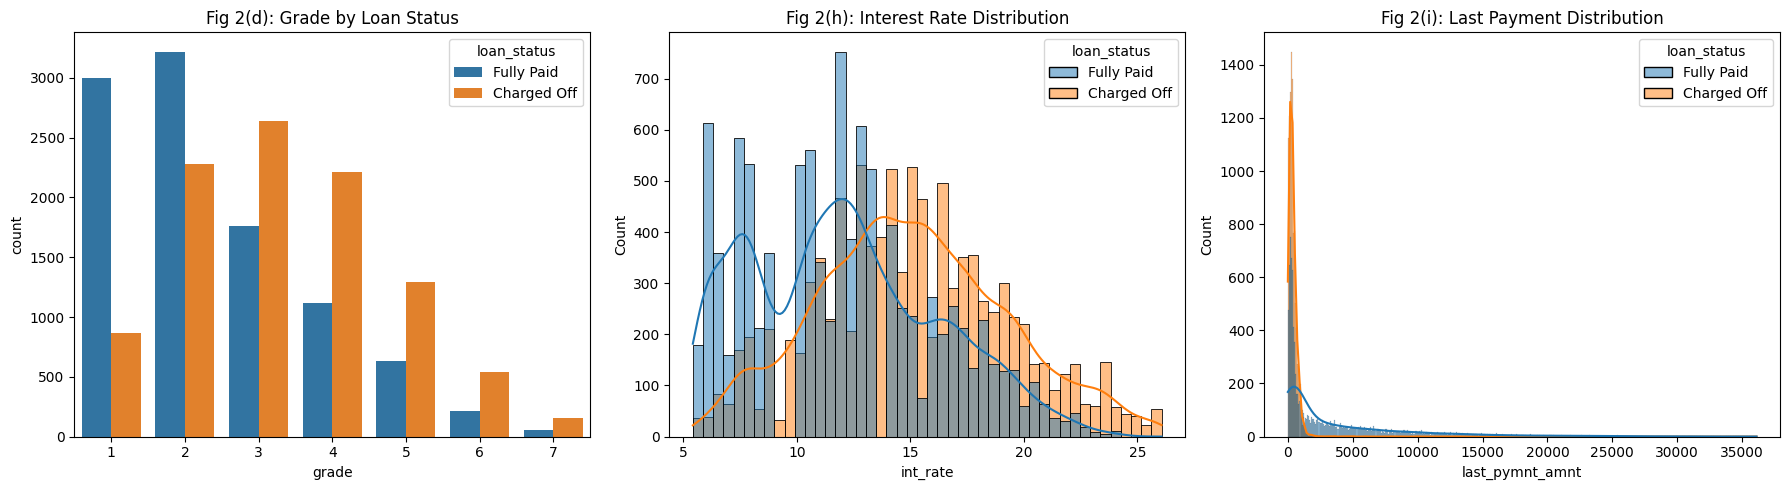

/tmp/ipython-input-2106473853.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_sample['issue_d'] = pd.to_datetime(df_sample['issue_d'])


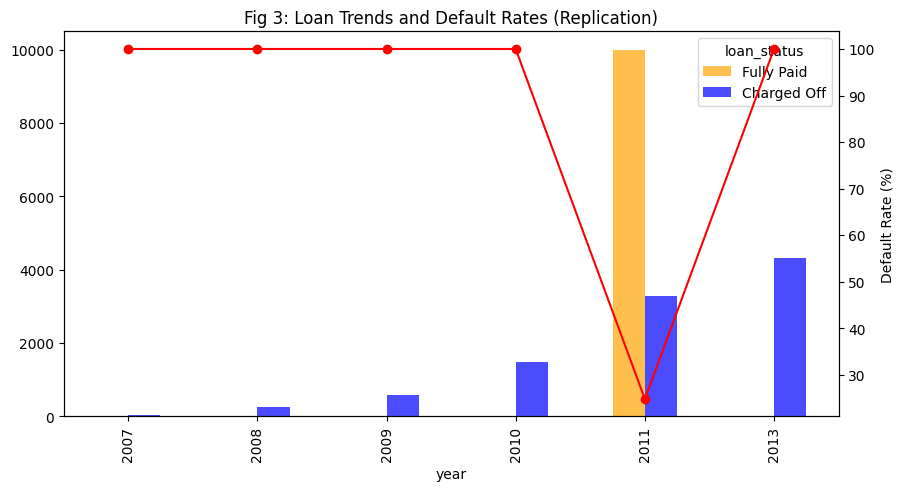

In [ ]:
# Replicating Figure 2 (Selected subplots)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Fig 2(d): Grade by loan status [cite: 169]
sns.countplot(data=df_sample, x='grade', hue='loan_status', ax=axes[0])
axes[0].set_title('Fig 2(d): Grade by Loan Status')

# Fig 2(h): Interest rate by loan status [cite: 171]
sns.histplot(data=df_sample, x='int_rate', hue='loan_status', kde=True, ax=axes[1])
axes[1].set_title('Fig 2(h): Interest Rate Distribution')

# Fig 2(i): Last payment amount by loan status [cite: 172]
sns.histplot(data=df_sample, x='last_pymnt_amnt', hue='loan_status', kde=True, ax=axes[2])
axes[2].set_title('Fig 2(i): Last Payment Distribution')

plt.tight_layout()
plt.show()

# Replicating Figure 3: Default Rates Over Time [cite: 177, 312]
df_sample['issue_d'] = pd.to_datetime(df_sample['issue_d'])
df_sample['year'] = df_sample['issue_d'].dt.year
year_stats = df_sample.groupby(['year', 'loan_status']).size().unstack(fill_value=0)
year_stats['Default Rate (%)'] = (year_stats['Charged Off'] / (year_stats['Charged Off'] + year_stats['Fully Paid'])) * 100

fig, ax1 = plt.subplots(figsize=(10, 5))
year_stats[['Fully Paid', 'Charged Off']].plot(kind='bar', ax=ax1, color=['orange', 'blue'], alpha=0.7)
ax2 = ax1.twinx()
ax2.plot(range(len(year_stats)), year_stats['Default Rate (%)'], color='red', marker='o')
ax2.set_ylabel('Default Rate (%)')
plt.title('Fig 3: Loan Trends and Default Rates (Replication)')
plt.show()